# Quantum Projection Learning (QPL) Tutorial

## Overview

**Quantum Projection Learning (QPL)** is an advanced quantum machine learning technique that extends Projected Quantum Kernels (PQK) by evaluating quantum-projected data with multiple classical machine learning algorithms. Instead of using only Support Vector Machines, QPL systematically compares performance across:

- **Support Vector Classifier (SVC)**
- **Random Forest (RF)**
- **XGBoost (XGB)**
- **Multi-Layer Perceptron (MLP)**
- **Logistic Regression (LR)**

This comprehensive approach helps identify which classical learner best exploits quantum feature representations for a given dataset.

### What You'll Learn

- Generate synthetic classification datasets with controlled complexity
- Configure and run QPL experiments using QProfiler
- Compare quantum-enhanced vs. classical baseline performance
- Analyze results across multiple models and embeddings
- Visualize performance metrics and identify where quantum features help

### Key Concepts

- **Quantum Feature Maps**: Transform classical data into quantum states
- **Quantum Projections**: Extract features from quantum circuits via expectation values
- **Ensemble Learning**: Combine multiple classical learners on quantum features
- **Data Complexity Analysis**: Understand which datasets benefit from quantum processing

---

## 1. Setup and Imports

First, configure the environment and import necessary libraries.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import re
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up paths
dir_home = re.sub('QBioCode.*', 'QBioCode', os.getcwd())
sys.path.append(dir_home)
sys.path.append(os.path.join(dir_home, 'apps'))

# Import QBioCode
import qbiocode as qbc
from qbiocode.apps.qprofiler import qprofiler as profiler

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✓ Environment configured successfully")
print(f"✓ Working directory: {os.getcwd()}")

<env>/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Environment configured successfully
✓ Working directory: <repo>/tutorial/Quantum_Projection_Learning


## 2. Understanding Quantum Projection Learning

### What is QPL?

Quantum Projection Learning works in three stages:

1. **Quantum Encoding**: Classical data is encoded into quantum states using parameterized quantum circuits (feature maps)
2. **Quantum Projection**: Expectation values of Pauli operators are measured, creating quantum-derived features
3. **Classical Learning**: Multiple classical ML models are trained on these quantum features

### Why Multiple Classifiers?

Different classifiers have different inductive biases:
- **SVC**: Effective for high-dimensional, non-linear boundaries
- **Random Forest**: Robust to noise, captures feature interactions
- **XGBoost**: Excellent for structured data, handles imbalanced classes
- **MLP**: Can learn complex non-linear patterns
- **Logistic Regression**: Simple, interpretable baseline

By testing all of them, we identify which best exploits quantum features for each dataset.

---

## 3. Generate Synthetic Test Data

We'll create artificial classification datasets with controlled properties to test QPL performance.

In [2]:
# Dataset configuration
type_of_data = 'classes'
save_path = os.path.join('data', 'qpl_tutorial_data')

# Dataset parameters. generate_data takes the *product* of these lists, so each value
# added here multiplies the run time; the settings below give 4 datasets.
#
# Feature count is the one to be careful with. With embeddings: ['none'] the feature
# map spends one qubit per feature, and simulating it costs exponentially more per
# qubit -- measured on a laptop, for 100 samples:
#
#      6 qubits    6.3s        12 qubits    25.4s
#      8 qubits    5.2s        15 qubits   138.3s
#
# This cell used to ask for 10-15 features across 32 datasets, which put the quantum
# cell alone near three hours. Staying at 6-8 shows the same behaviour in minutes.
N_SAMPLES = [100]                   # Number of samples per dataset
N_FEATURES = [6, 8]                 # Number of features -- and so of qubits
N_INFORMATIVE = [4]                 # Number of informative features
N_REDUNDANT = [2]                   # Number of redundant features
N_CLASSES = [2]                     # Binary classification
N_CLUSTERS_PER_CLASS = [2]          # Clusters per class
WEIGHTS = [[0.3, 0.7], [0.5, 0.5]]  # Class imbalance scenarios

print("Generating synthetic datasets...")
print(f"  - Data type: {type_of_data}")
print(f"  - Sample sizes: {N_SAMPLES}")
print(f"  - Feature dimensions: {N_FEATURES}")
print(f"  - Class weights: {WEIGHTS}")

# Generate datasets
qbc.generate_data(
    type_of_data=type_of_data,
    save_path=save_path,
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_classes=N_CLASSES,
    n_clusters_per_class=N_CLUSTERS_PER_CLASS,
    weights=WEIGHTS,
)

print(f"\n✓ Datasets generated and saved to: {save_path}")

# List generated files
if os.path.exists(save_path):
    files = sorted(f for f in os.listdir(save_path) if f.endswith('.csv'))
    print(f"✓ Generated {len(files)} dataset files")
    for f in files:
        print(f"  - {f}")


Generating synthetic datasets...
  - Data type: classes
  - Sample sizes: [100]
  - Feature dimensions: [6, 8]
  - Class weights: [[0.3, 0.7], [0.5, 0.5]]
Generating classes dataset...
Dataset generation complete.

✓ Datasets generated and saved to: data/qpl_tutorial_data
✓ Generated 4 dataset files
  - class_data-1.csv
  - class_data-2.csv
  - class_data-3.csv
  - class_data-4.csv


## 4. Configure QPL Experiment

QProfiler uses YAML configuration files to specify experimental parameters. Let's examine the QPL configuration.

In [3]:
# Load and display QPL configuration
qpl_config_path = 'configs/qpl.yaml'

with open(qpl_config_path, 'r') as f:
    qpl_config = yaml.safe_load(f)

print("QPL Configuration:")
print("=" * 60)
print(yaml.dump(qpl_config, default_flow_style=False, sort_keys=False))
print("=" * 60)

print("\nKey Configuration Parameters:")
print(f"  - Model: {qpl_config.get('model', 'N/A')}")
print(f"  - Backend: {qpl_config.get('backend', 'N/A')}")
print(f"  - Data directory: {qpl_config.get('folder_path', 'N/A')}")
print(f"  - Embeddings: {qpl_config.get('embeddings', 'N/A')}")

if 'pqk' in qpl_config:
    print("\n  PQK-specific parameters:")
    for key, value in qpl_config['pqk'].items():
        print(f"    - {key}: {value}")

QPL Configuration:
config_file_name: basic_config
folder_path: data/qpl_tutorial_data
file_dataset: ALL
backend: simulator
qiskit_json_path: ~/.qiskit/qiskit-ibm.json
name: cleveland_clinic
n_jobs: 9
embeddings:
- none
n_components: 3
model:
- qpl
average: weighted
multi_class: raise
seed: 42
q_seed: 42
shots: 1024
resil_level: 1
test_size: 0.3
stratify:
- y
scaling:
- 'True'
grid_search: false
cross_validation: 5
NN_depth: 1
iter: 3
svc_args:
  C: 0.01
  gamma: 0.1
  kernel: linear
gridsearch_svc_args:
  C:
  - 0.1
  - 1
  - 10
  - 100
  gamma:
  - 0.001
  - 0.01
  - 0.1
  - 1
  kernel:
  - linear
  - rbf
  - poly
  - sigmoid
dt_args:
  criterion: gini
  max_depth: null
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: null
gridsearch_dt_args:
  criterion:
  - gini
  - entropy
  - log_loss
  max_depth:
  - null
  - 5
  - 10
  - 15
  - 20
  min_samples_split:
  - 2
  - 5
  - 10
  - 15
  min_samples_leaf:
  - 1
  - 2
  - 4
  - 6
  max_features:
  - null
  - sqrt
  - log2
nb_a

## 5. Run QPL Experiment

Execute the QPL experiment using QProfiler. This will:
1. Load the generated datasets
2. Apply quantum feature maps
3. Extract quantum projections
4. Train all 5 classical models on quantum features
5. Evaluate performance and save results

In [4]:
print("=" * 80)
print("RUNNING QUANTUM PROJECTION LEARNING EXPERIMENT")
print("=" * 80)

# QProfiler *appends* to ModelResults.csv, which is what lets the quantum run here and
# the classical baselines in the next cell accumulate into one comparable table. The
# same append means a second pass through this notebook would silently double every
# row, so clear the previous pass's output first and start from a known state.
for stale in ('ModelResults.csv', 'RawDataEvaluation.csv'):
    if os.path.exists(stale):
        os.remove(stale)
        print(f"Removed {stale} left by an earlier run")

print("\nQPL projects each sample through a quantum feature map, then fits five")
print("classical learners on the resulting expectation values, so this single run")
print("produces qpl_svc, qpl_rf, qpl_xgb, qpl_mlp and qpl_lr rows.")
print("Expect a few minutes: cost scales with datasets x splits x samples, and")
print("exponentially with the qubit count (= feature count) chosen above.\n")

# Run QPL experiment
profiler.main(qpl_config)

print("\n" + "=" * 80)
print("✓ QPL EXPERIMENT COMPLETED")
print("=" * 80)


RUNNING QUANTUM PROJECTION LEARNING EXPERIMENT

QPL projects each sample through a quantum feature map, then fits five
classical learners on the resulting expectation values, so this single run
produces qpl_svc, qpl_rf, qpl_xgb, qpl_mlp and qpl_lr rows.
Expect a few minutes: cost scales with datasets x splits x samples, and
exponentially with the qubit count (= feature count) chosen above.

Processing file: class_data-1.csv
at datapoint 0


at datapoint 0


qpl_rf


qpl_mlp


qpl_svc
qpl_lr


...

qpl_rf


qpl_mlp


qpl_svc
qpl_lr


qpl_xgb



✓ QPL EXPERIMENT COMPLETED


## 6. Run Classical Baselines (XGBoost and Random Forest)

A quantum result is only interesting next to a classical one that was given the same
chance, so we run two tuned baselines on the original (non-quantum) features. Both
read the datasets generated above and append to the same results table, so the next
section can compare all of them side by side.


In [5]:
print("=" * 80)
print("RUNNING CLASSICAL BASELINES (XGBoost, Random Forest)")
print("=" * 80)

# Two baselines rather than one. A quantum result only means something against a
# classical model that was itself tuned, and rf.yaml already existed in configs/ --
# fully configured, and loaded by nothing.
for config_name in ('configs/xgb.yaml', 'configs/rf.yaml'):
    baseline_config = yaml.safe_load(open(config_name, 'r'))

    print(f"\n--- {config_name} ---")
    print(f"  - Model: {baseline_config.get('model', 'N/A')}")
    print(f"  - Data directory: {baseline_config.get('folder_path', 'N/A')}")
    print(f"  - Embeddings: {baseline_config.get('embeddings', 'N/A')}")
    print(f"  - Grid search: {baseline_config.get('grid_search', False)}\n")

    profiler.main(baseline_config)

print("\n" + "=" * 80)
print("✓ CLASSICAL BASELINES COMPLETED")
print("=" * 80)


RUNNING CLASSICAL BASELINES (XGBoost, Random Forest)

--- configs/xgb.yaml ---
  - Model: ['xgb']
  - Data directory: data/qpl_tutorial_data
  - Embeddings: ['none']
  - Grid search: True

Processing file: class_data-1.csv


Processing file: class_data-2.csv


Processing file: class_data-3.csv


Processing file: class_data-4.csv



--- configs/rf.yaml ---
  - Model: ['rf']
  - Data directory: data/qpl_tutorial_data
  - Embeddings: ['none']
  - Grid search: True

Processing file: class_data-1.csv


Processing file: class_data-2.csv


Processing file: class_data-3.csv


Processing file: class_data-4.csv



✓ CLASSICAL BASELINES COMPLETED


## 7. Load and Compile Results

Collect all results from the experiments and compile them into comprehensive DataFrames.

In [6]:
print("Loading experimental results...\n")

# Find all result files
data_eval_files = [
    os.path.join(dp, f) 
    for dp, dn, filenames in os.walk(os.getcwd()) 
    for f in filenames 
    if f == 'RawDataEvaluation.csv'
]

model_result_files = [
    os.path.join(dp, f) 
    for dp, dn, filenames in os.walk(os.getcwd()) 
    for f in filenames 
    if f == 'ModelResults.csv'
]

print(f"Found {len(data_eval_files)} data evaluation files")
print(f"Found {len(model_result_files)} model result files\n")

# Load and compile data complexity evaluations
if data_eval_files:
    rawevals_df = pd.concat([pd.read_csv(f) for f in data_eval_files], ignore_index=True)
    rawevals_df.to_csv('compiled_raw_data_evaluations.csv', index=False)
    print(f"✓ Data evaluations compiled: {rawevals_df.shape}")
    print(f"  Saved to: compiled_raw_data_evaluations.csv")
else:
    print("⚠ No data evaluation files found")
    rawevals_df = pd.DataFrame()

# Load and compile model results
if model_result_files:
    results_df = pd.concat([pd.read_csv(f) for f in model_result_files], ignore_index=True)
    
    # Add useful columns for analysis
    results_df['datatype'] = results_df['Dataset'].str.replace('-.*', '', regex=True)
    results_df['model_embed_datatype'] = (
        results_df['model'] + '_' + 
        results_df['embeddings'] + '_' + 
        results_df['datatype']
    )
    results_df['model_datatype'] = (
        results_df['model'] + '_' + results_df['datatype']
    )
    
    results_df.to_csv('compiled_results.csv', index=False)
    print(f"\n✓ Model results compiled: {results_df.shape}")
    print(f"  Saved to: compiled_results.csv")
    
    # Display summary statistics
    print("\nResults Summary:")
    print(f"  - Unique datasets: {results_df['Dataset'].nunique()}")
    print(f"  - Models tested: {results_df['model'].unique().tolist()}")
    print(f"  - Embeddings used: {results_df['embeddings'].unique().tolist()}")
    print(f"  - Metrics available: {[col for col in results_df.columns if 'score' in col or 'accuracy' in col or 'auc' in col]}")
else:
    print("⚠ No model result files found")
    results_df = pd.DataFrame()

print("\n" + "=" * 80)

# Shared by the plotting cells below. These used to be defined inside the plotting
# cell's `else:` branch, so the analysis cell after it raised NameError on any run
# where there were no results to plot -- exactly the run where you want the message,
# not a traceback.
output_dir = 'performance_summary_and_spearman_correlation_plots'
tag = 'qpl_tutorial'
os.makedirs(output_dir, exist_ok=True)


Loading experimental results...

Found 1 data evaluation files
Found 1 model result files

✓ Data evaluations compiled: (4, 24)
  Saved to: compiled_raw_data_evaluations.csv

✓ Model results compiled: (84, 35)
  Saved to: compiled_results.csv

Results Summary:
  - Unique datasets: 4
  - Models tested: ['qpl_lr', 'qpl_mlp', 'qpl_rf', 'qpl_svc', 'qpl_xgb', 'xgb_opt', 'rf_opt']
  - Embeddings used: ['none']
  - Metrics available: ['accuracy', 'f1_score', 'auc']



## 8. Performance Visualization

Create comprehensive visualizations comparing quantum and classical performance.

Generating performance visualizations...



✓ Saved: performance_summary_and_spearman_correlation_plots/qpl_tutorial_f1_score_boxplot.png


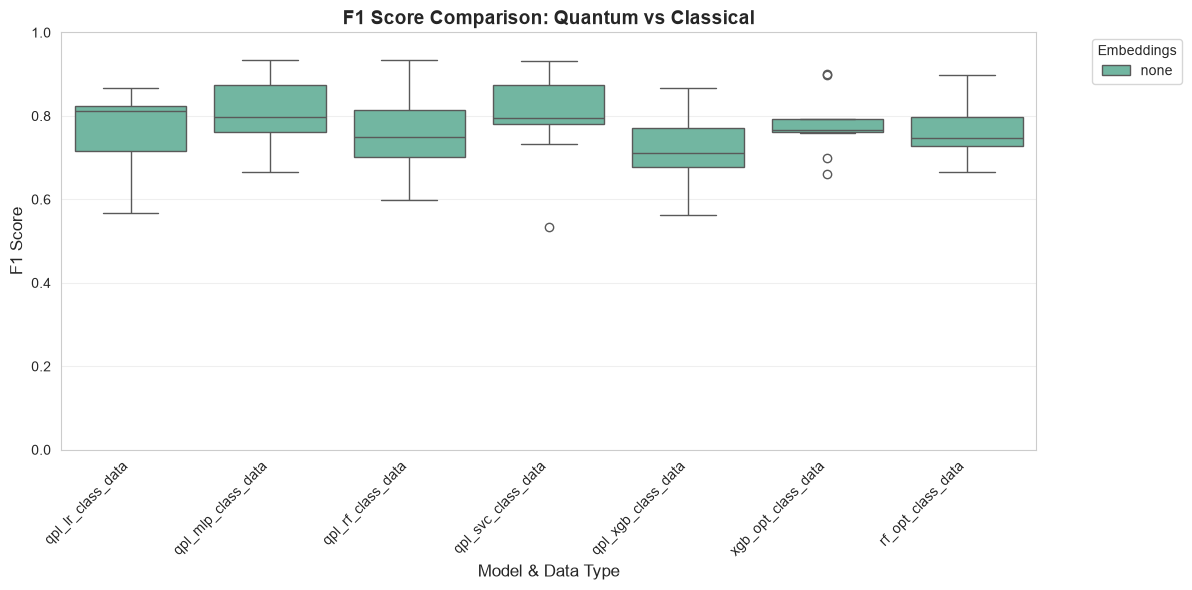

✓ Saved: performance_summary_and_spearman_correlation_plots/qpl_tutorial_accuracy_boxplot.png


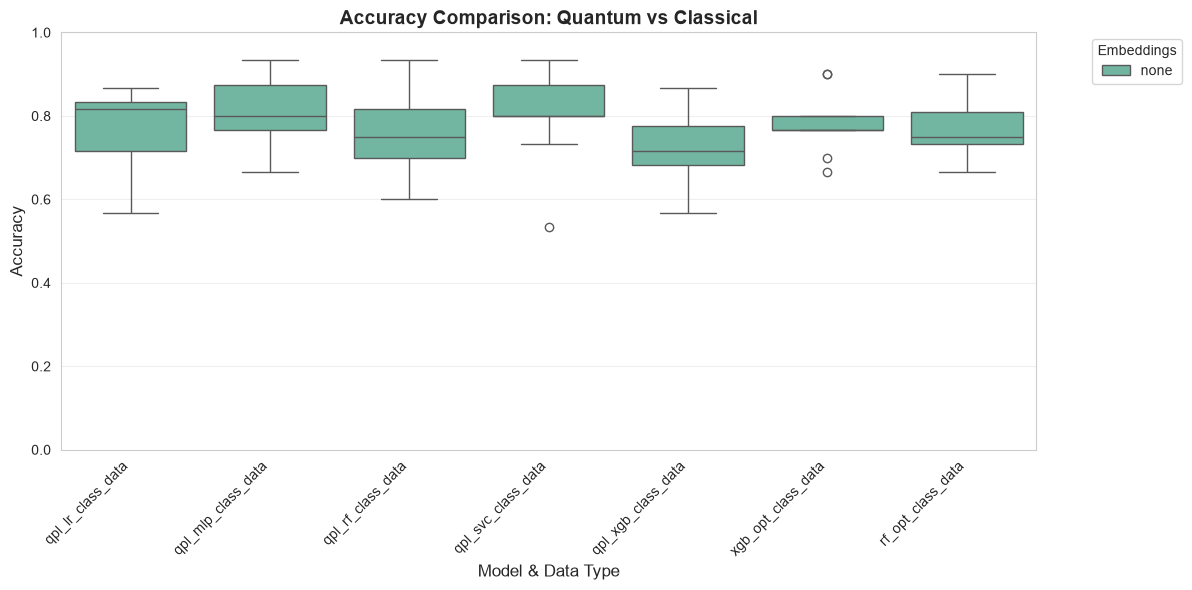

✓ Saved: performance_summary_and_spearman_correlation_plots/qpl_tutorial_auc_boxplot.png


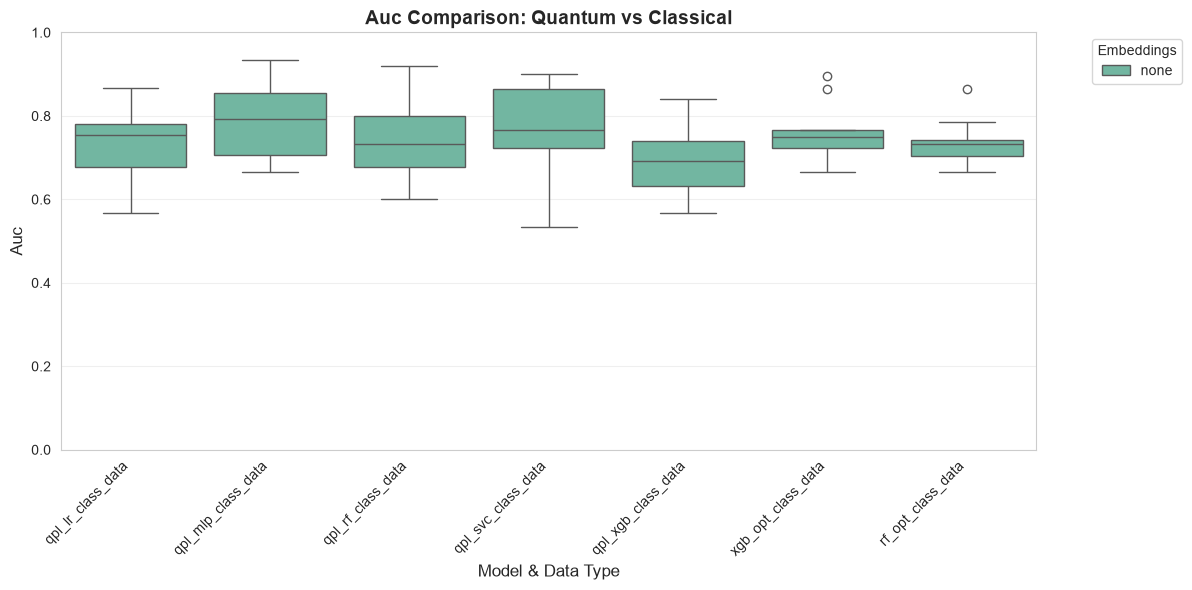


✓ All visualizations saved to: performance_summary_and_spearman_correlation_plots/


In [7]:
if results_df.empty:
    print("⚠ No results to visualize. Please run the experiments first.")
else:
    print("Generating performance visualizations...\n")
    
    # Plot performance metrics
    metrics = ['f1_score', 'accuracy', 'auc']
    
    for metric in metrics:
        if metric not in results_df.columns:
            print(f"⚠ Metric '{metric}' not found in results")
            continue
            
        plt.figure(figsize=(12, 6))
        
        # Create boxplot
        sns.boxplot(
            data=results_df, 
            x='model_datatype', 
            y=metric, 
            hue='embeddings',
            palette='Set2'
        )
        
        plt.ylim(0, 1)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Model & Data Type', fontsize=12)
        plt.ylabel(metric.replace('_', ' ').title(), fontsize=12)
        plt.title(f'{metric.replace("_", " ").title()} Comparison: Quantum vs Classical', 
                  fontsize=14, fontweight='bold')
        plt.legend(title='Embeddings', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        
        # Save figure
        filename = os.path.join(output_dir, f'{tag}_{metric}_boxplot.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {filename}")
        
        plt.show()
        plt.close()
    
    print(f"\n✓ All visualizations saved to: {output_dir}/")

## 9. Quantum vs. Classical Comparison

Identify datasets where quantum methods outperform classical baselines.

Comparing quantum and classical models...

Quantum models in results:   ['qpl_lr', 'qpl_mlp', 'qpl_rf', 'qpl_svc', 'qpl_xgb']
Classical models in results: ['rf_opt', 'xgb_opt']

Total datasets analyzed: 4
Datasets where QML won: 2
Quantum win rate: 50.0%

Datasets where a quantum model ranked first:
--------------------------------------------------------------------------------
  class_data-2.csv                         | qpl_svc      | F1: 0.8667
  class_data-3.csv                         | qpl_rf       | F1: 0.8534



✓ Quantum vs. classical plot saved: performance_summary_and_spearman_correlation_plots/qpl_tutorial_quantum_vs_classical.png


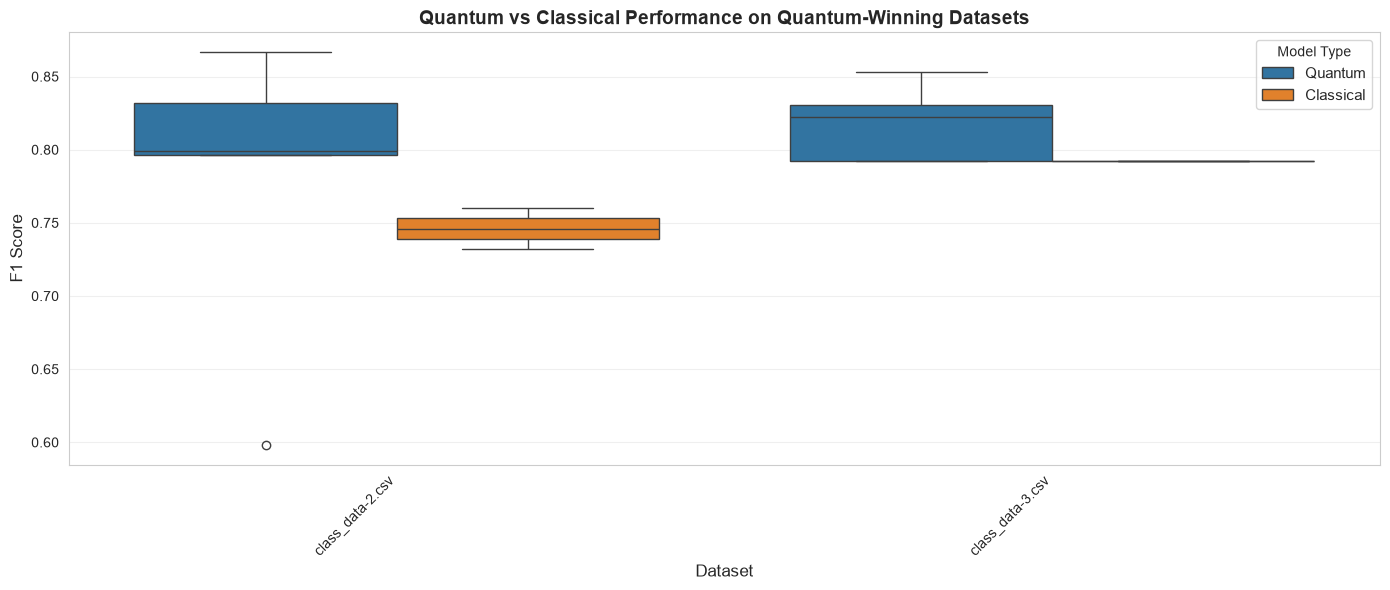

In [8]:
if results_df.empty:
    print("⚠ No results to analyze")
else:
    print("Comparing quantum and classical models...\n")
    print("=" * 80)
    
    # Read the quantum model names out of the results rather than hard-coding them.
    # This list used to be ['pqk_lr', 'pqk_svc', 'pqk_rf', 'pqk_mlp', 'pqk_xgb'] -- the
    # five QPL learner names wearing the PQK prefix, which is a set the pipeline can
    # never produce under either model. Nothing matched, so `qml_winners` was always
    # empty and the win rate printed 0.0% however well the quantum models did.
    quantum_prefixes = ('qpl', 'pqk', 'qsvc', 'qnn', 'vqc')
    qml_models = sorted(
        m for m in results_df['model'].unique() if str(m).startswith(quantum_prefixes)
    )
    print(f"Quantum models in results:   {qml_models}")
    print(f"Classical models in results: "
          f"{sorted(set(results_df['model'].unique()) - set(qml_models))}\n")
    
    # Calculate median F1 score across splits for each dataset/model combination
    df_median = results_df.groupby(['Dataset', 'embeddings', 'model'])['f1_score'].median().reset_index()
    
    # Find best model for each dataset
    best_per_dataset = df_median.loc[df_median.groupby('Dataset')['f1_score'].idxmax()]
    
    # Identify datasets where quantum models won
    qml_winners = best_per_dataset[best_per_dataset['model'].isin(qml_models)]
    
    print(f"Total datasets analyzed: {df_median['Dataset'].nunique()}")
    print(f"Datasets where QML won: {len(qml_winners)}")
    print(f"Quantum win rate: {len(qml_winners) / df_median['Dataset'].nunique() * 100:.1f}%\n")
    
    if len(qml_winners) > 0:
        print("Datasets where a quantum model ranked first:")
        print("-" * 80)
        for idx, row in qml_winners.iterrows():
            print(f"  {row['Dataset']:40s} | {row['model']:12s} | F1: {row['f1_score']:.4f}")
        
        # Create comparison plot
        qml_winner_data = df_median[df_median['Dataset'].isin(qml_winners['Dataset'])].copy()
        qml_winner_data['model_type'] = qml_winner_data['model'].apply(
            lambda x: 'Quantum' if x in qml_models else 'Classical'
        )
        
        plt.figure(figsize=(14, 6))
        ax = sns.boxplot(
            data=qml_winner_data, 
            x='Dataset', 
            y='f1_score', 
            hue='model_type',
            palette={'Quantum': '#1f77b4', 'Classical': '#ff7f0e'}
        )
        
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Dataset', fontsize=12)
        plt.ylabel('F1 Score', fontsize=12)
        plt.title('Quantum vs Classical Performance on Quantum-Winning Datasets', 
                  fontsize=14, fontweight='bold')
        plt.legend(title='Model Type', fontsize=11)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        
        filename = os.path.join(output_dir, f'{tag}_quantum_vs_classical.png')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"\n✓ Quantum vs. classical plot saved: {filename}")
        
        plt.show()
        plt.close()
    else:
        print("⚠ No datasets found where quantum models outperformed classical baselines.")
        print("   This could indicate:")
        print("   - Datasets are too simple to separate quantum from classical")
        print("   - Classical models are well-suited for these problems")
        print("   - More complex quantum feature maps may be needed")
    
    print("\n" + "=" * 80)

## 10. Model Performance Summary

Generate a comprehensive summary table of all model performances.

In [9]:
if not results_df.empty:
    print("Model Performance Summary")
    print("=" * 80)
    
    # Calculate average performance by model
    summary = results_df.groupby('model').agg({
        'f1_score': ['mean', 'std', 'min', 'max'],
        'accuracy': ['mean', 'std'],
        'auc': ['mean', 'std']
    }).round(4)
    
    print("\nAverage Performance by Model:")
    print(summary.to_string())
    
    # Identify best models
    print("\n" + "-" * 80)
    print("Best Performing Models:")
    print("-" * 80)
    
    for metric in ['f1_score', 'accuracy', 'auc']:
        if metric in results_df.columns:
            best_model = results_df.groupby('model')[metric].mean().idxmax()
            best_score = results_df.groupby('model')[metric].mean().max()
            print(f"  {metric:15s}: {best_model:15s} ({best_score:.4f})")
    
    print("\n" + "=" * 80)
else:
    print("⚠ No results available for summary")

Model Performance Summary

Average Performance by Model:
        f1_score                         accuracy             auc        
            mean     std     min     max     mean     std    mean     std
model                                                                    
qpl_lr    0.7618  0.1003  0.5662  0.8667   0.7667  0.0995  0.7373  0.0885
qpl_mlp   0.8074  0.0826  0.6652  0.9333   0.8083  0.0818  0.7922  0.0877
qpl_rf    0.7577  0.0982  0.5982  0.9333   0.7611  0.0983  0.7360  0.0916
qpl_svc   0.8032  0.1039  0.5333  0.9307   0.8083  0.1036  0.7731  0.1066
qpl_xgb   0.7176  0.0933  0.5623  0.8667   0.7222  0.0946  0.6897  0.0800
rf_opt    0.7613  0.0631  0.6667  0.8982   0.7667  0.0651  0.7354  0.0524
xgb_opt   0.7796  0.0682  0.6606  0.9014   0.7833  0.0674  0.7577  0.0659

--------------------------------------------------------------------------------
Best Performing Models:
--------------------------------------------------------------------------------
  f1_score      

## Key Takeaways

### What We Learned

1. **QPL Workflow**: Successfully applied quantum projection learning with multiple classical learners
2. **Model Comparison**: Systematically compared 5+ models on quantum-projected features
3. **Quantum vs. Classical**: Identified datasets where quantum features scored higher
4. **Comprehensive Analysis**: Used data complexity metrics to understand performance patterns

### Best Practices

- **Multiple Models**: Test various classifiers to find the best match for quantum features
- **Baseline Comparison**: Always compare against strong classical baselines
- **Data Complexity**: Analyze dataset characteristics to predict where quantum features help
- **Systematic Evaluation**: Use cross-validation and multiple metrics for robust assessment

### When to Use QPL

QPL is most effective when:
- Dataset has complex, non-linear structure
- Feature interactions are important
- Classical methods plateau in performance
- You want to explore multiple learning algorithms

### Next Steps

- Experiment with different quantum feature maps (Z, ZZ, Pauli)
- Adjust entanglement strategies (linear, full, circular, pairwise)
- Try different numbers of repetitions (`reps`)
- Test on real-world datasets (genomics, medical imaging, etc.)
- Explore quantum hardware execution
- Combine with other quantum algorithms (VQC, QNN)

### Configuration Tips

**For faster experiments:**
```yaml
backend: simulator
reps: 2
n_components: 5
```

**For better accuracy:**
```yaml
backend: simulator
reps: 8
n_components: 10
entanglement: pairwise
```

**For quantum hardware:**
```yaml
backend: ibm_quantum
device: ibm_brisbane  # or your preferred device
```

### References

- [QBioCode Documentation](https://qiskit-community.github.io/QBioCode/)
- [QProfiler Guide](https://qiskit-community.github.io/QBioCode/apps/profiler.html)
- [Qiskit Machine Learning](https://qiskit.org/ecosystem/machine-learning/)
- [Quantum Feature Maps](https://qiskit.org/textbook/ch-machine-learning/quantum-feature-maps.html)

---

**Questions or Issues?** Open an issue on [GitHub](https://github.com/qiskit-community/QBioCode/issues)